In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)

from randomness import *
from df_metrics import *
from simulation_exact import *
from utils import *
from data_analysis import *
from main import *
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
from itertools import product

#seed = 42
#np.random.seed(seed)
#rng = np.random.default_rng(seed)

In [3]:
use_loss = 'hinge' #'log' or 'hinge' or 'squared_hinge' 
sigma_loss = 1.0 
c = 1.0 # choose c without scaling 
show_plots = False # set to True to see plots of the binary search
is_throw = True # set to True to throw out points outside margin --> only when loss is lipschitz. 
k = None # if none will be set based on data max norm
k_coef = 1.0 # coefficient to multiply k with
fit_intercept = True # whether to fit intercept in SVM model
d = 4 #[2, 4, 8, 16, 32, 64] # dimensions to run experiments on
T = 50  # number of trials

In [4]:
def generate_gaus_data(n_pos, n_neg, mu_pos, mu_neg, sigma_pos, sigma_neg, rng, d=1):
    X_neg = rng.normal(loc=mu_neg, scale=sigma_neg, size=(n_neg, d)) # label -1 
    X_pos = rng.normal(loc=mu_pos, scale=sigma_pos, size=(n_pos, d)) # label 1 
    X = np.vstack([X_neg, X_pos])
    y = np.concatenate([-1 * np.ones(n_neg),np.ones(n_pos)])

    v = np.concatenate([np.ones(n_pos),  np.ones(n_neg)])  # generate_v_data(n_neg, n_pos, rng)
    return X, y, v

In [5]:
# choose parameters 
ms = [2**i for i in range(15, 25)]

n_val_pos = 200
n_val_neg = 200

mu_pos_scalar = 0.2 # class 1 mean
mu_neg_scalar = -0.2 # class -1 mean

mu_pos =  np.concatenate(([mu_pos_scalar], np.zeros(d - 1)))
mu_neg =  np.concatenate(([mu_neg_scalar], np.zeros(d - 1)))

sigmas = [0.1, 0.2, 0.5, 1,1.5, 2 , 2.5] #np.linspace(2, 0.1, 31) # different sigmas to run the experiments on

In [6]:
# run exact sisigmalation
# returns df with cols "agent" | "true_v" | "critical_v" | "allocation" | "welfare" | "utility"
# utility = welfare - payment
# welfare = allocation * true_v
# critical_v = payment 

def compute_metrics_gaus_2(t):
    dfs = []
    for m in ms:
        for sigma in sigmas:
            seed = hash((t, m, sigma)) % (2**32)
            rng = np.random.default_rng(seed)
            x, y, v =  generate_gaus_data(m//2, m//2, mu_pos, mu_neg, sigma, sigma, rng, d)
            #x_val, y_val, _ =  generate_gaus_data(n_val_pos, n_val_neg, mu_pos, mu_neg, sigma, sigma, rng, d)
            
            df_exact, svm_model = run_exact(x, y, v, c, use_loss, sigma_loss=sigma_loss, plot=show_plots, 
                                    is_throw=is_throw, k=k, k_coef=k_coef, fit_intercept=fit_intercept)
            df_exact['t'] = t
            df_exact['d'] = d
            df_exact['sigma'] = sigma
            df_exact['m_total'] = m
            #df_exact['valid_acc'] = svm_model.score(x_val,y_val)
            df_exact['label'] = y[df_exact['agent'].astype(int)]
            dfs.append(df_exact)

    return pd.concat(dfs, ignore_index=True)

In [37]:
mega_df = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_2)(t) for t in range(T)
        ), 
        ignore_index=True
)

In [ ]:
d = 16
mu_pos =  np.concatenate(([mu_pos_scalar], np.zeros(d - 1)))
mu_neg =  np.concatenate(([mu_neg_scalar], np.zeros(d - 1)))
mega_df_16_2 = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_2)(t) for t in range(T)
        ), 
        ignore_index=True
)

alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999


In [10]:
mega_df_16_2.to_csv("output_vary_sigma_2.csv", index=False)

In [8]:
d = 16
is_throw = True 
mu_pos =  np.concatenate(([mu_pos_scalar], np.zeros(d - 1)))
mu_neg =  np.concatenate(([mu_neg_scalar], np.zeros(d - 1)))
mega_df_16_2 = pd.concat(  
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_metrics_gaus_2)(t) for t in range(T)
        ), 
        ignore_index=True
)

alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999
alloc mid = 0
high, low 1.0 1.0
critical_v = None
iter = 9999


In [14]:
mega_df_16_2['d'].unique()

array([16])

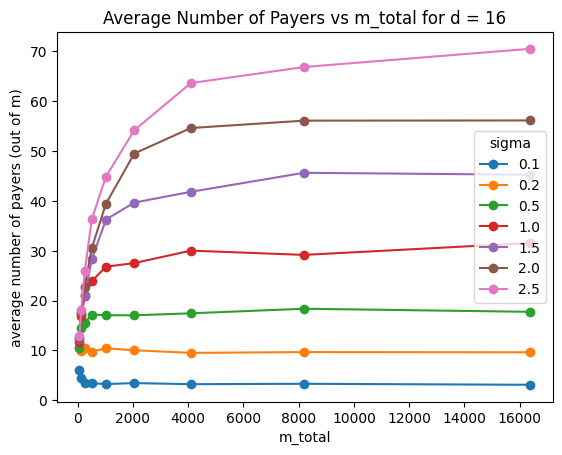

In [ ]:
plot_mean_num_payers_m(mega_df_16_2, d = 16, labels = [1, -1])

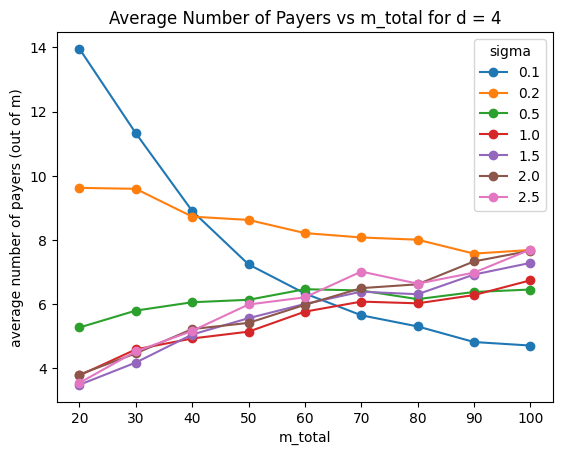

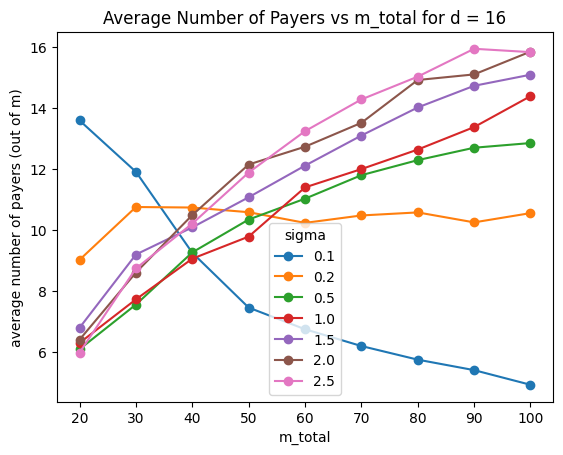

In [40]:
plot_mean_num_payers_m(mega_df, d = 4, labels = [1, -1])
plot_mean_num_payers_m(mega_df_16, d = 16, labels = [1, -1])

In [46]:
mean_num_payers = (
                        mega_df[(mega_df['label'].isin([1,-1])) 
                                   & (mega_df['m_total'] == 100)
                                  ]
                        .assign(pos=lambda df: df['critical_v'] > 0)
                        .groupby(['sigma', 'm_total'])['pos']
                        .sum()
                        .unstack(level = 0)
                        / T
                    )
mean_num_payers16 = (
                        mega_df_16[(mega_df_16['label'].isin([1,-1])) 
                                   & (mega_df_16['m_total'] == 100)
                                  ]
                        .assign(pos=lambda df: df['critical_v'] > 0)
                        .groupby(['sigma', 'm_total'])['pos']
                        .sum()
                        .unstack(level = 0)
                        / T
                    )

In [47]:
mean_num_payers

sigma,0.1,0.2,0.5,1.0,1.5,2.0,2.5
m_total,,,,,,,
100,4.706667,7.686667,6.453333,6.74,7.283333,7.663333,7.7


In [48]:
mean_num_payers16

sigma,0.1,0.2,0.5,1.0,1.5,2.0,2.5
m_total,,,,,,,
100,4.92,10.546667,12.843333,14.38,15.083333,15.84,15.823333


In [3]:
df = pd.read_csv('output_vary_sigma_2.csv')